# Practical 4 — Dimensionality Reduction, Geometric Learning & Clustering

**Machine Learning for Bioinformatics**

## Flow
1. PCA from first principles — expression data
2. PCA with `scikit-learn` + biological interpretation
3. PCA vs t-SNE vs UMAP
4. KNN and SVM — supervised geometric learning
5. Clustering — microscopy-derived features
6. Synthesis

> Recurring question: **What is a sample? What is a feature? What defines similarity? What information is preserved or lost?**


## Learning objectives
Students should be able to:
- explain PCA as centering → covariance → eigendecomposition → projection;
- distinguish scores, loadings, and explained variance;
- interpret PCA loadings biologically;
- compare PCA, t-SNE, and UMAP;
- explore t-SNE/UMAP hyperparameters;
- explain scaling for KNN/SVM;
- compare KNN with linear/RBF SVM;
- avoid preprocessing leakage;
- apply K-means, hierarchical clustering, and DBSCAN;
- distinguish computational clusters from biological classes.


## 0. Setup

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import umap.umap_ as umap
from sklearn.cluster import DBSCAN, AgglomerativeClustering, KMeans
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score,
    adjusted_rand_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    normalized_mutual_info_score,
    silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from pathlib import Path

RANDOM_STATE = 300926


C:\Users\user\Desktop\kse\practicals\kse-github\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Part I — PCA from first principles

## 1. Expression dataset
**Dataset:** from my article

- Organism: *Mus musculus* (the feature IDs are Ensembl mouse gene IDs, `ENSMUSG...`).
- Tissue/cell type: bladder-related samples; the sample names contain source descriptors.
- Groups: `Detrusor` and `Urothelium`, supplied in `metadata.csv`.
- Samples: 5 total (2 Detrusor and 3 Urothelium).
- Genes/features: 35,551 rows in `counts.csv`.
- Metadata: sample ID and condition.
- Biological question: do the samples separate by the broad bladder tissue group, and which genes drive that separation?

The files are deliberately small in the sample dimension, which makes them useful for learning PCA. They are not sufficient for strong biological inference: with five samples, PCA has at most four non-zero centered components.


In [84]:
counts_raw = pd.read_csv("counts.csv")
metadata = pd.read_csv("metadata.csv")


In [85]:
counts_raw

,gene_id,SRR15142383_Detrusor_Only,SRR15142384_Whole_Bladder,SRR21930966_urothelium,SRR23185420_LFD_Female_11614,SRR23185421_LFD_Female_11613
0,ENSMUSG00000000001,8530.000,18076.000,899.000,503.0,586.000
1,ENSMUSG00000000003,0.000,0.000,0.000,0.0,0.000
2,ENSMUSG00000000028,247.245,594.786,5.000,4.0,7.000
3,ENSMUSG00000000037,162.999,151.000,8.000,0.0,10.000
4,ENSMUSG00000000049,38.000,43.000,2.000,0.0,0.000
...,...,...,...,...,...,...
35546,ENSMUSG00000121598,0.000,0.000,0.000,0.0,0.000
35547,ENSMUSG00000121599,0.000,0.000,0.000,0.0,0.000
35548,ENSMUSG00000121600,0.000,0.000,0.000,0.0,0.000
35549,ENSMUSG00001074846,6.000,0.000,0.000,0.0,0.000


In [86]:
metadata

,sample,condition
0,SRR15142383_Detrusor_Only,Detrusor
1,SRR15142384_Whole_Bladder,Detrusor
2,SRR21930966_urothelium,Urothelium
3,SRR23185420_LFD_Female_11614,Urothelium
4,SRR23185421_LFD_Female_11613,Urothelium


In [87]:
expression_counts = counts_raw.set_index("gene_id").T
expression_counts.index.name = "sample"
expression_counts

gene_id,ENSMUSG00000000001,ENSMUSG00000000003,ENSMUSG00000000028,ENSMUSG00000000037,ENSMUSG00000000049,ENSMUSG00000000056,ENSMUSG00000000058,ENSMUSG00000000078,ENSMUSG00000000085,ENSMUSG00000000088,...,ENSMUSG00000121592,ENSMUSG00000121593,ENSMUSG00000121594,ENSMUSG00000121596,ENSMUSG00000121597,ENSMUSG00000121598,ENSMUSG00000121599,ENSMUSG00000121600,ENSMUSG00001074846,ENSMUSG00002076083
sample,,,,,,,,,,,,,,,,,,,,,
SRR15142383_Detrusor_Only,8530.0,0.0,247.245,162.999,38.0,1942.0,4213.001,95163.0,4276.999,33956.999,...,0.0,0.0,0.0,711.232,0.0,0.0,0.0,0.0,6.0,373.826
SRR15142384_Whole_Bladder,18076.0,0.0,594.786,151.000,43.0,4105.0,13189.000,78884.0,9459.001,94266.000,...,0.0,0.0,0.0,1350.809,0.0,0.0,0.0,0.0,0.0,740.702
SRR21930966_urothelium,899.0,0.0,5.000,8.000,2.0,149.0,730.000,2085.0,391.000,792.000,...,0.0,0.0,0.0,15.568,0.0,0.0,0.0,0.0,0.0,86.628
SRR23185420_LFD_Female_11614,503.0,0.0,4.000,0.000,0.0,80.0,908.000,313.0,112.000,498.000,...,0.0,0.0,0.0,24.022,0.0,0.0,0.0,0.0,0.0,31.000
SRR23185421_LFD_Female_11613,586.0,0.0,7.000,10.000,0.0,112.0,950.000,392.0,202.001,709.000,...,0.0,0.0,0.0,18.000,0.0,0.0,0.0,0.0,0.0,48.699


In [88]:
#Normalisation in divided log scale and keeping top 1000 genes by variation
library_sizes = expression_counts.sum(axis=1)
cpm = expression_counts.div(library_sizes, axis=0) * 1_000_000
log_cpm = np.log1p(cpm)
detected = (expression_counts > 0).sum(axis=0) >= 2
expression = log_cpm.loc[:, detected]
gene_variances = expression.var(axis=0).sort_values(ascending=False)
TOP_N_GENES = 1000
feature_names = gene_variances.head(TOP_N_GENES).index.tolist()
expression_pca = expression.loc[:, feature_names]
print("Raw matrix:", expression_counts.shape, "; PCA matrix:", expression_pca.shape)


Raw matrix: (5, 35551) ; PCA matrix: (5, 1000)


In [89]:
expression_pca

gene_id,ENSMUSG00000100862,ENSMUSG00000062456,ENSMUSG00000006313,ENSMUSG00000022435,ENSMUSG00000106037,ENSMUSG00000054146,ENSMUSG00000068893,ENSMUSG00000043461,ENSMUSG00000028435,ENSMUSG00000101111,...,ENSMUSG00000048332,ENSMUSG00000023868,ENSMUSG00000026961,ENSMUSG00000038132,ENSMUSG00000042303,ENSMUSG00000027208,ENSMUSG00000020473,ENSMUSG00000036095,ENSMUSG00000117694,ENSMUSG00000027245
sample,,,,,,,,,,,,,,,,,,,,,
SRR15142383_Detrusor_Only,0.000000,7.419965,0.184646,0.184646,7.137380,0.179817,1.536207,0.017233,0.231694,0.000000,...,4.670695,3.213960,0.022912,3.131460,1.723888,3.180809,6.750634,2.899653,3.321435,4.934533
SRR15142384_Whole_Bladder,0.000000,8.014519,6.161415,6.902316,7.170393,6.921656,7.836037,5.893969,5.345433,0.000000,...,4.680825,1.945165,1.966454,2.442946,2.777765,2.675988,5.940223,2.470937,3.404278,5.261340
SRR21930966_urothelium,6.304970,0.000000,8.615557,8.381647,3.307253,8.708203,9.182142,7.310983,7.879926,0.000000,...,1.172246,0.000000,3.563769,0.000000,5.415890,0.000000,4.486361,0.000000,1.092582,1.946510
SRR23185420_LFD_Female_11614,8.335463,0.000000,9.428909,9.008526,0.000000,8.180297,9.944878,7.941424,7.864445,5.691131,...,3.514609,0.000000,3.107852,0.000000,4.291670,0.000000,3.074933,0.000000,0.000000,2.572058
SRR23185421_LFD_Female_11613,8.752321,0.000000,9.199954,8.752336,0.000000,8.346482,9.537312,8.104729,7.789953,6.330690,...,4.384888,0.000000,3.445343,0.415069,4.552737,1.728159,4.030803,0.000000,1.443145,2.945370


In [90]:

metadata = metadata.set_index("sample")
metadata


,condition
sample,
SRR15142383_Detrusor_Only,Detrusor
SRR15142384_Whole_Bladder,Detrusor
SRR21930966_urothelium,Urothelium
SRR23185420_LFD_Female_11614,Urothelium
SRR23185421_LFD_Female_11613,Urothelium


## 2. Initial data inspection

In [91]:
print("Fraction of zero entries in the count table:", round(float((expression_counts == 0).to_numpy().mean()), 3))
print("Fraction of non-integer abundance values:", round(float(((expression_counts.to_numpy() % 1) != 0).mean()), 3))


Fraction of zero entries in the count table: 0.484
Fraction of non-integer abundance values: 0.199


### Questions
1. What is one observation?
2. What is one feature?
4. Are values counts, normalized counts, log-expression, etc.?

## 3. PCA Step 1 — Center the data


In [92]:
X = expression_pca.to_numpy(dtype=float)
feature_means = X.mean(axis=0)
X_centered = X - feature_means


print(float(np.abs(X_centered.mean(axis=0)).max()))


1.4210854715202005e-15


## 4. Optional scaling

For each feature, unit-variance scaling is

\[
z_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j}.
\]

Should every gene contribute equal variance? For this small expression example, we use log-CPM and select variable genes, but do not scale each gene to unit variance in the main PCA. Unit-variance scaling would give low-abundance/noisy genes the same influence as highly variable genes.


In [93]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Centered-only range:", (X_centered.min(), X_centered.max()))
print("Scaled feature means (first 5):", X_scaled.mean(axis=0)[:5])


Centered-only range: (np.float64(-6.5334502689146925), np.float64(4.927622167101985))
Scaled feature means (first 5): [ 0.00000000e+00 -4.44089210e-17 -4.44089210e-17 -1.11022302e-16
 -8.88178420e-17]


## 5. PCA Step 2 — Covariance

After centering, the sample covariance matrix is

\[
C = \frac{1}{n-1} X_c^{\mathsf{T}} X_c.
\]

In [94]:
covariance_matrix = (X_centered.T @ X_centered) / (X_centered.shape[0] - 1)
covariance_matrix.shape


(1000, 1000)

In [95]:
covariance_matrix

array([[ 19.09788198, -18.05275415,  14.07033387, ...,  -6.28164499,
         -5.9526371 ,  -5.78287925],
       [-18.05275415,  17.91093317, -13.23487684, ...,   6.18505973,
          5.8348668 ,   6.06678911],
       [ 14.07033387, -13.23487684,  15.02608797, ...,  -5.08006677,
         -4.48517847,  -4.29815835],
       ...,
       [ -6.28164499,   6.18505973,  -5.08006677, ...,   2.18621776,
          2.0237212 ,   2.08503814],
       [ -5.9526371 ,   5.8348668 ,  -4.48517847, ...,   2.0237212 ,
          2.18564634,   1.99176371],
       [ -5.78287925,   6.06678911,  -4.29815835, ...,   2.08503814,
          1.99176371,   2.18427943]], shape=(1000, 1000))

## 6. PCA Step 3 — Eigenvalues and eigenvectors

The principal directions satisfy the eigenvalue equation

\[
C v_k = \lambda_k v_k.
\]

- \(v_k\): principal direction / loading vector
- \(\lambda_k\): variance captured along that direction

Because this dataset has only five samples, the centered matrix has at most four non-zero directions. Rather than diagonalizing the full 1,000 × 1,000 covariance matrix, we use the mathematically equivalent 5 × 5 sample-space covariance matrix and reconstruct the feature-space loading vectors.

In [96]:
n_samples, n_features = X_centered.shape
sample_covariance = (X_centered @ X_centered.T) / (n_samples - 1)
sample_eigenvalues, sample_eigenvectors = np.linalg.eigh(sample_covariance)
order = np.argsort(sample_eigenvalues)[::-1]
sample_eigenvalues = sample_eigenvalues[order]
sample_eigenvectors = sample_eigenvectors[:, order]
sample_eigenvectors

array([[-0.67821088, -0.05787608, -0.5797874 ,  0.02295497,  0.4472136 ],
       [-0.3861836 , -0.04905829,  0.79704922, -0.11475213,  0.4472136 ],
       [ 0.42448511, -0.76647404, -0.06849703,  0.1662471 ,  0.4472136 ],
       [ 0.374556  ,  0.32414294, -0.15438799, -0.72856263,  0.4472136 ],
       [ 0.26535337,  0.54926546,  0.0056232 ,  0.65411269,  0.4472136 ]])

In [97]:

# Recover feature-space eigenvectors from the small eigendecomposition.
positive = sample_eigenvalues > 1e-10
eigenvalues = sample_eigenvalues[positive]
eigenvectors = (X_centered.T @ sample_eigenvectors[:, positive]) / np.sqrt((n_samples - 1) * eigenvalues)

residual = np.linalg.norm(covariance_matrix @ eigenvectors[:, 0] - eigenvalues[0] * eigenvectors[:, 0])
print("Diagonalized matrix shape:", sample_covariance.shape)
print("Non-zero components:", len(eigenvalues))
print("Largest eigenvalues:", eigenvalues)
print("First eigenvector equation residual:", residual)


Diagonalized matrix shape: (5, 5)
Non-zero components: 4
Largest eigenvalues: [3179.25082833  312.14839197  212.15490938   50.87635267]
First eigenvector equation residual: 8.998041938604264e-13


## 7. Explained variance

PC1: 0.847
PC1 + PC2: 0.93


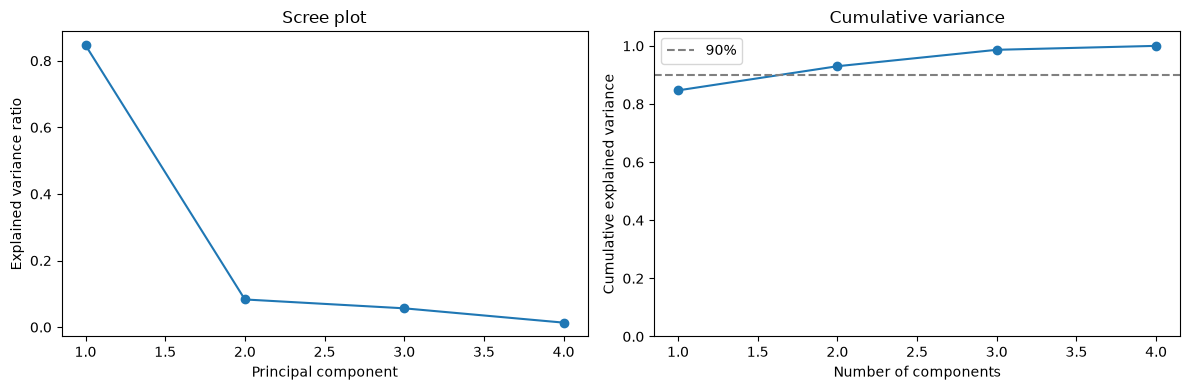

In [98]:
explained_variance_ratio = eigenvalues / eigenvalues.sum()
cumulative_variance = np.cumsum(explained_variance_ratio)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(np.arange(1, len(eigenvalues) + 1), explained_variance_ratio, marker="o")
axes[0].set(xlabel="Principal component", ylabel="Explained variance ratio", title="Scree plot")
axes[1].plot(np.arange(1, len(eigenvalues) + 1), cumulative_variance, marker="o")
axes[1].axhline(0.90, color="grey", linestyle="--", label="90%")
axes[1].set(xlabel="Number of components", ylabel="Cumulative explained variance", title="Cumulative variance")
axes[1].set_ylim(0, 1.05)
axes[1].legend()
plt.tight_layout()
print("PC1:", round(float(explained_variance_ratio[0]), 3))
print("PC1 + PC2:", round(float(cumulative_variance[1]), 3))


## 8. PCA Step 4 — Projection

\[
Z = X_cV
\]

Rows of \(Z\) are sample **scores**.


In [99]:
scores = X_centered @ eigenvectors
pca_manual = pd.DataFrame(scores[:, :2], index=expression_pca.index, columns=["PC1", "PC2"])
display(pca_manual)


,PC1,PC2
sample,,
SRR15142383_Detrusor_Only,-76.481632,-2.045077
SRR15142384_Whole_Bladder,-43.549806,-1.733496
SRR21930966_urothelium,47.869055,-27.083700
SRR23185420_LFD_Female_11614,42.238565,11.453734
SRR23185421_LFD_Female_11613,29.923818,19.408539


## 9. PC1 vs PC2

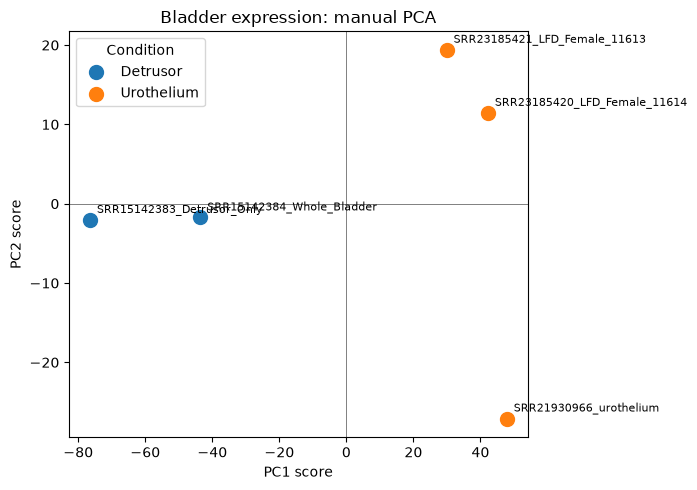

In [100]:
scores_with_metadata = pca_manual.join(metadata)
fig, ax = plt.subplots(figsize=(7, 5))
for condition, group in scores_with_metadata.groupby("condition"):
    ax.scatter(group["PC1"], group["PC2"], s=100, label=condition)
    for sample, row in group.iterrows():
        ax.annotate(sample, (row["PC1"], row["PC2"]), xytext=(5, 5), textcoords="offset points", fontsize=8)
ax.set(xlabel="PC1 score", ylabel="PC2 score", title="Bladder expression: manual PCA")
ax.axhline(0, color="grey", linewidth=0.7)
ax.axvline(0, color="grey", linewidth=0.7)
ax.legend(title="Condition")
plt.tight_layout()


### Interpretation
- Which metadata correlate with PC1/PC2?
- Is separation biological or technical?
- Are replicates positioned as expected?
- Are there outliers?


## 10. Loadings and biological interpretation


1. Rank genes/features by loading.
2. Inspect positive and negative tails.
3. Look for markers/pathways.
4. Compare with metadata and experimental biology.


In [101]:
loadings = pd.DataFrame({
    "feature": feature_names,
    "PC1": eigenvectors[:, 0],
    "PC2": eigenvectors[:, 1]
})
display(loadings.nsmallest(10, "PC1"))
display(loadings.nlargest(10, "PC1"))


,feature,PC1,PC2
1,ENSMUSG00000062456,-0.072071,-0.023280
13,ENSMUSG00000055148,-0.057283,-0.006593
4,ENSMUSG00000106037,-0.055031,-0.093384
20,ENSMUSG00000071076,-0.054200,-0.027872
21,ENSMUSG00000091955,-0.053613,-0.003270
24,ENSMUSG00000054702,-0.052213,-0.022034
31,ENSMUSG00000080921,-0.051503,-0.016534
29,ENSMUSG00000039452,-0.050964,-0.030862
37,ENSMUSG00000105207,-0.050847,-0.000062
40,ENSMUSG00000091119,-0.050825,0.015957


,feature,PC1,PC2
0,ENSMUSG00000100862,0.072013,0.075749
2,ENSMUSG00000006313,0.063185,0.033761
3,ENSMUSG00000022435,0.057318,0.026992
15,ENSMUSG00000054545,0.056472,0.017673
10,ENSMUSG00000000385,0.056072,0.012147
5,ENSMUSG00000054146,0.054804,0.005984
8,ENSMUSG00000028435,0.054414,0.014505
6,ENSMUSG00000068893,0.053962,0.026910
16,ENSMUSG00000078664,0.053547,0.025574
7,ENSMUSG00000043461,0.052680,0.032035


# Part II — PCA vs t-SNE vs UMAP

The expression dataset above has only five samples. That is too small for a meaningful t-SNE/UMAP comparison. For this part we use different data from my article: one row per microscopy cell, with a 512-dimensional VGG16 embedding and external metadata (`test` and `Value`).

We will use a deterministic 2,500-cell subset for runtime control. 


## 12. PCA baseline on microscopy-cell embeddings

In [102]:
microscopy = pd.read_csv("cell_vgg16_embeddings_sample_10pct.csv.gz", compression="gzip")
microscopy

,crop_path,vgg_0,vgg_1,vgg_2,vgg_3,vgg_4,vgg_5,vgg_6,vgg_7,vgg_8,...,vgg_508,vgg_509,vgg_510,vgg_511,filename,cell_id,image_path,mask_path,Value,test
0,seg_results\derived\crops\01082025_CTDX014_C9_...,3.946904,0.000000,6.305725,0.060684,0.000000,1.134654,2.479789,0.361916,0.000000,...,0.675538,0.000000,0.011338,0.033564,01082025_CTDX014_C9.tif,722.0,seg_results\overlays\01082025_CTDX014_C9_overl...,seg_results\masks\01082025_CTDX014_C9_mask.tiff,138.500000,Alamar
1,seg_results\derived\crops\01082025_CTDX015_C3_...,1.599527,0.000000,1.841917,0.302870,0.000000,0.195952,0.469308,0.294746,0.000000,...,2.978592,0.000000,0.000000,0.000000,01082025_CTDX015_C3.tif,473.0,seg_results\overlays\01082025_CTDX015_C3_overl...,seg_results\masks\01082025_CTDX015_C3_mask.tiff,97.500000,Alamar
2,seg_results\derived\crops\01082025_CTDX014_E3_...,0.923420,0.000000,1.349434,0.029401,0.000000,0.000000,1.759340,0.180807,0.159884,...,0.000000,0.461538,3.558034,0.047436,01082025_CTDX014_E3.tif,220.0,seg_results\overlays\01082025_CTDX014_E3_overl...,seg_results\masks\01082025_CTDX014_E3_mask.tiff,192.900000,Alamar
3,seg_results\derived\crops\01082025_CTDX014_G11...,1.099776,0.000000,1.387042,0.010555,0.019562,0.663436,0.351477,0.758568,0.000000,...,0.873062,0.083298,0.131222,0.000000,01082025_CTDX014_G11.tif,83.0,seg_results\overlays\01082025_CTDX014_G11_over...,seg_results\masks\01082025_CTDX014_G11_mask.tiff,178.600000,Alamar
4,seg_results\derived\crops\01082025_CTDX014_G11...,1.319530,0.000000,5.730895,0.592967,0.000000,1.110529,0.281516,0.000000,0.776721,...,1.077945,0.000000,0.522702,0.000000,01082025_CTDX014_G11.tif,461.0,seg_results\overlays\01082025_CTDX014_G11_over...,seg_results\masks\01082025_CTDX014_G11_mask.tiff,178.600000,Alamar
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27047,seg_results\derived\crops\Pluronic.500_81_cell...,2.272418,0.000000,2.663519,0.000000,0.000000,0.364062,0.262355,0.046916,0.043826,...,0.345465,0.477931,0.297494,0.135320,Pluronic.500_81.tif,418.0,seg_results\overlays\Pluronic.500_81_overlay.png,seg_results\masks\Pluronic.500_81_mask.tiff,118.235556,MTT
27048,seg_results\derived\crops\Pluronic.500_79_cell...,2.134527,0.000000,5.359082,0.040893,0.159605,0.805649,4.774994,0.644259,0.003884,...,1.309363,0.000000,0.058097,0.036036,Pluronic.500_79.tif,473.0,seg_results\overlays\Pluronic.500_79_overlay.png,seg_results\masks\Pluronic.500_79_mask.tiff,118.235556,MTT
27049,seg_results\derived\crops\Pluronic.50_96_cell4...,0.187803,0.000000,0.403680,0.010158,0.542536,0.636951,0.027108,1.036794,0.046423,...,0.915319,0.040499,6.120120,0.000000,Pluronic.50_96.tif,407.0,seg_results\overlays\Pluronic.50_96_overlay.png,seg_results\masks\Pluronic.50_96_mask.tiff,117.777778,MTT
27050,seg_results\derived\crops\PAR50.500_66_cell162...,0.025176,0.537180,0.014643,0.029196,0.057247,0.378472,0.005162,0.127577,0.000000,...,0.000000,2.373482,5.735575,0.000000,PAR50.500_66.tif,1628.0,seg_results\overlays\PAR50.500_66_overlay.png,seg_results\masks\PAR50.500_66_mask.tiff,16.936667,MTT


In [103]:

vgg_columns = [column for column in microscopy.columns if column.startswith("vgg_")]
microscopy = microscopy.dropna(subset=vgg_columns + ["test", "Value"]).reset_index(drop=True)
X_embedding_raw = microscopy[vgg_columns].to_numpy(dtype=np.float32)
embedding_test = microscopy["test"].astype(str).to_numpy()
embedding_value = microscopy["Value"].to_numpy(dtype=float)


In [104]:
# Standardize before PCA because VGG coordinates can have different scales.
embedding_scaler = StandardScaler()
X_embedding_scaled = embedding_scaler.fit_transform(X_embedding_raw)
embedding_pca = PCA(n_components=30, svd_solver="randomized", random_state=RANDOM_STATE)
X_embedding_pca = embedding_pca.fit_transform(X_embedding_scaled)
X_embedding_pca

array([[-5.853619  ,  3.606976  ,  9.353564  , ..., -0.29627654,
         0.13102773, -0.39405626],
       [-6.0965533 , -2.0913918 , -1.9807364 , ..., -0.03869027,
         0.14888063, -1.0789351 ],
       [ 0.85046005, -1.5367723 , -4.784699  , ...,  0.02141241,
         0.9413265 , -0.56194025],
       ...,
       [-1.7237532 , -6.670087  , -2.3863401 , ...,  0.27718782,
        -0.01838586,  1.9153326 ],
       [-0.5823747 , -2.075391  , -9.77817   , ...,  0.78653866,
        -0.05757195, -0.44339323],
       [15.844934  ,  2.2560258 ,  1.1861168 , ...,  1.3569471 ,
        -4.205488  ,  2.0126288 ]], shape=(27052, 30), dtype=float32)

In [105]:
rng = np.random.default_rng(RANDOM_STATE)
N_NONLINEAR = 2500
embedding_indices = rng.choice(len(X_embedding_pca), size=N_NONLINEAR, replace=False)
X_nonlinear = X_embedding_pca[embedding_indices]
X_nonlinear_scaled = X_embedding_scaled[embedding_indices]
embedding_test_subset = embedding_test[embedding_indices]
embedding_value_subset = embedding_value[embedding_indices]

print("Embedding table:", microscopy.shape)
print("VGG feature count:", len(vgg_columns))
print("PCA representation:", X_nonlinear.shape)
print("External test labels:", pd.Series(embedding_test_subset).value_counts().to_dict())


Embedding table: (27052, 519)
VGG feature count: 512
PCA representation: (2500, 30)
External test labels: {'Alamar': 1624, 'MTT': 876}


### 12.1 Inspect the external metadata

`test` is categorical, whereas `Value` is continuous. Inspect both before interpreting an embedding: a continuous variable should usually be shown with a color scale, not treated as a class label.


Value summary:


,Value
count,2500.000000
mean,124.666248
std,54.892425
min,2.454000
25%,96.240000
50%,116.600000
75%,159.300000
max,271.664444


Number of unique Value measurements: 351


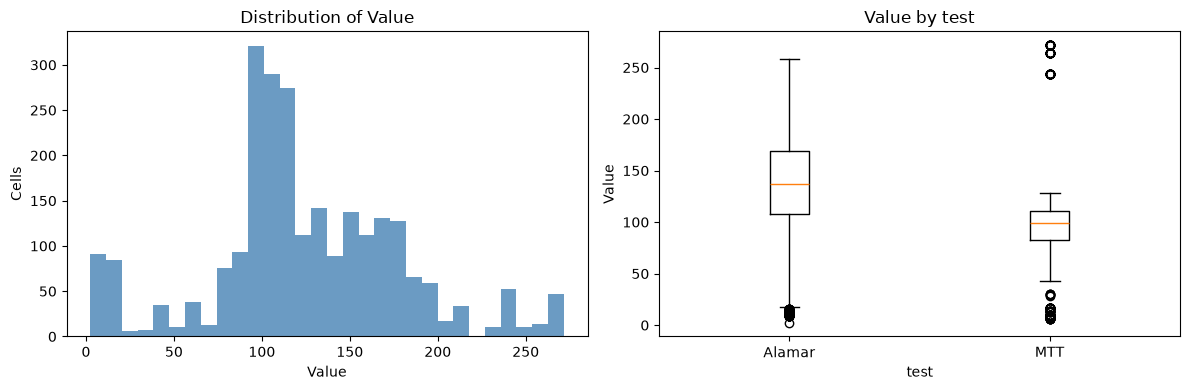

In [106]:
value_summary = pd.Series(embedding_value_subset, name="Value").describe()
print("Value summary:")
display(value_summary.to_frame())
print("Number of unique Value measurements:", pd.Series(embedding_value_subset).nunique())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(embedding_value_subset, bins=30, color="steelblue", alpha=0.8)
axes[0].set(xlabel="Value", ylabel="Cells", title="Distribution of Value")
value_by_test = [embedding_value_subset[embedding_test_subset == label] for label in sorted(np.unique(embedding_test_subset))]
axes[1].boxplot(value_by_test, tick_labels=sorted(np.unique(embedding_test_subset)))
axes[1].set(xlabel="test", ylabel="Value", title="Value by test")
plt.tight_layout()


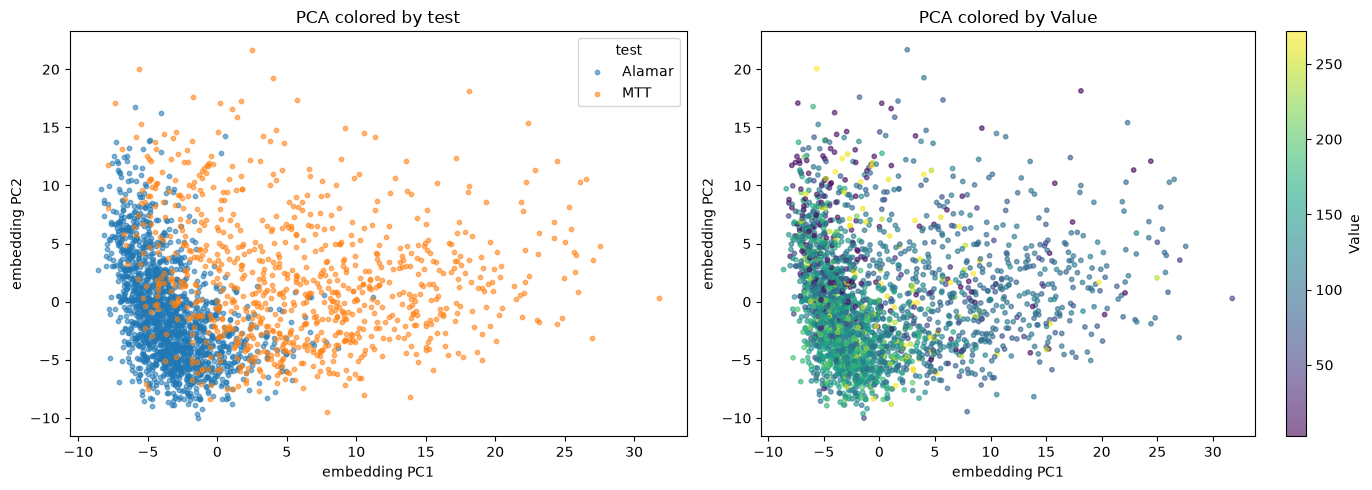

In [107]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label in sorted(np.unique(embedding_test_subset)):
    mask = embedding_test_subset == label
    axes[0].scatter(X_nonlinear[mask, 0], X_nonlinear[mask, 1], s=10, alpha=0.55, label=label)
axes[0].set(xlabel="embedding PC1", ylabel="embedding PC2", title="PCA colored by test")
axes[0].legend(title="test")
value_plot = axes[1].scatter(X_nonlinear[:, 0], X_nonlinear[:, 1], c=embedding_value_subset, cmap="viridis", s=10, alpha=0.6)
axes[1].set(xlabel="embedding PC1", ylabel="embedding PC2", title="PCA colored by Value")
fig.colorbar(value_plot, ax=axes[1], label="Value")
plt.tight_layout()


## 13. t-SNE

In [108]:
tsne = TSNE(n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    max_iter=750,
    random_state=RANDOM_STATE)

X_tsne = tsne.fit_transform(X_nonlinear)
X_tsne

array([[-21.855326  ,   3.3761907 ],
       [ -0.86386216, -25.17776   ],
       [-26.468065  , -12.798638  ],
       ...,
       [-16.696245  , -21.07323   ],
       [-24.702843  ,  -7.085617  ],
       [-13.872587  ,   5.997796  ]], shape=(2500, 2), dtype=float32)

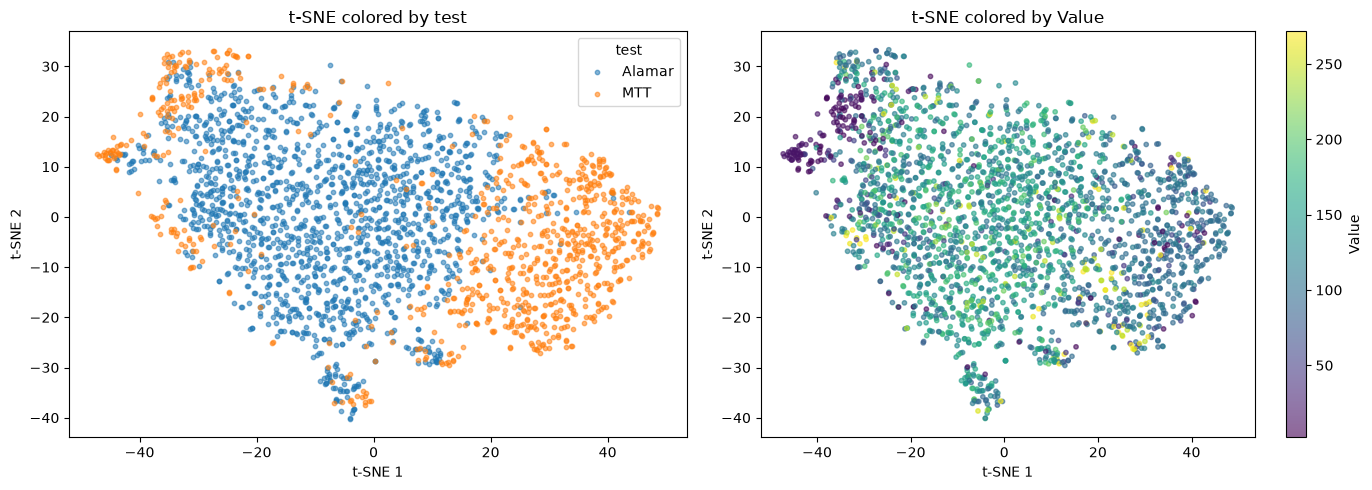

In [109]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label in sorted(np.unique(embedding_test_subset)):
    mask = embedding_test_subset == label
    axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=10, alpha=0.55, label=label)
axes[0].set(xlabel="t-SNE 1", ylabel="t-SNE 2", title="t-SNE colored by test")
axes[0].legend(title="test")
value_plot = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=embedding_value_subset, cmap="viridis", s=10, alpha=0.6)
axes[1].set(xlabel="t-SNE 1", ylabel="t-SNE 2", title="t-SNE colored by Value")
fig.colorbar(value_plot, ax=axes[1], label="Value")
plt.tight_layout()


### 13.1 perplexity tuning

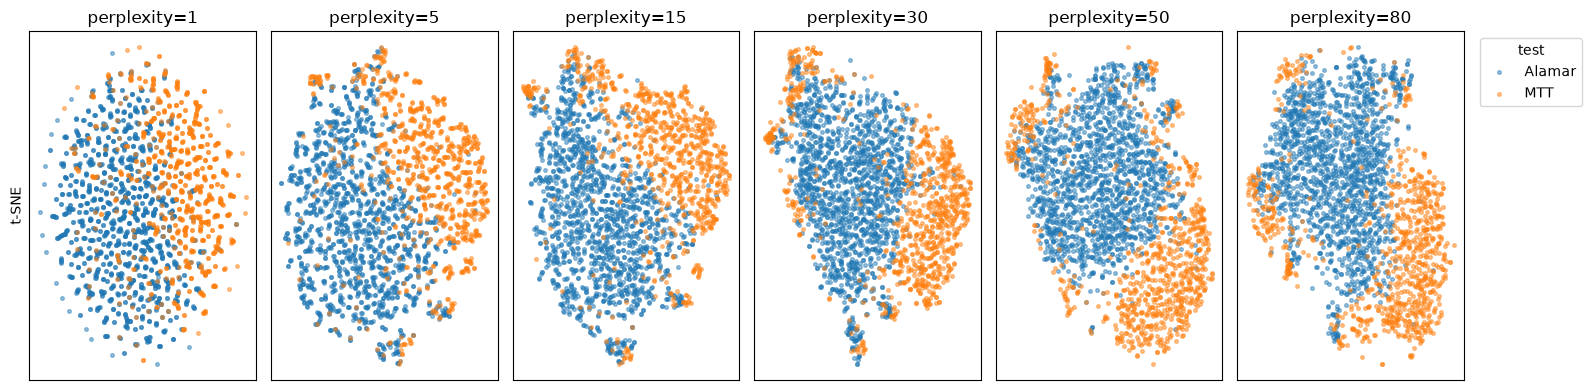

In [110]:
perplexities = [1, 5, 15, 30, 50, 80]
fig, axes = plt.subplots(1, len(perplexities), figsize=(16, 4))
for ax, perplexity in zip(axes, perplexities):
    embedding = TSNE(
        n_components=2, perplexity=perplexity, init="pca",
        learning_rate="auto", max_iter=750, random_state=RANDOM_STATE
    ).fit_transform(X_nonlinear)
    for label in sorted(np.unique(embedding_test_subset)):
        mask = embedding_test_subset == label
        ax.scatter(embedding[mask, 0], embedding[mask, 1], s=7, alpha=0.45, label=label)
    ax.set_title(f"perplexity={perplexity}")
    ax.set_xticks([])
    ax.set_yticks([])
axes[0].set_ylabel("t-SNE")
axes[-1].legend(title="test", bbox_to_anchor=(1.04, 1), loc="upper left")
plt.tight_layout()


### Questions
- Which structures remain stable?
- Which structures change?
- Are distances between islands quantitatively meaningful?
- Is apparent cluster size biologically meaningful?


## 14. UMAP

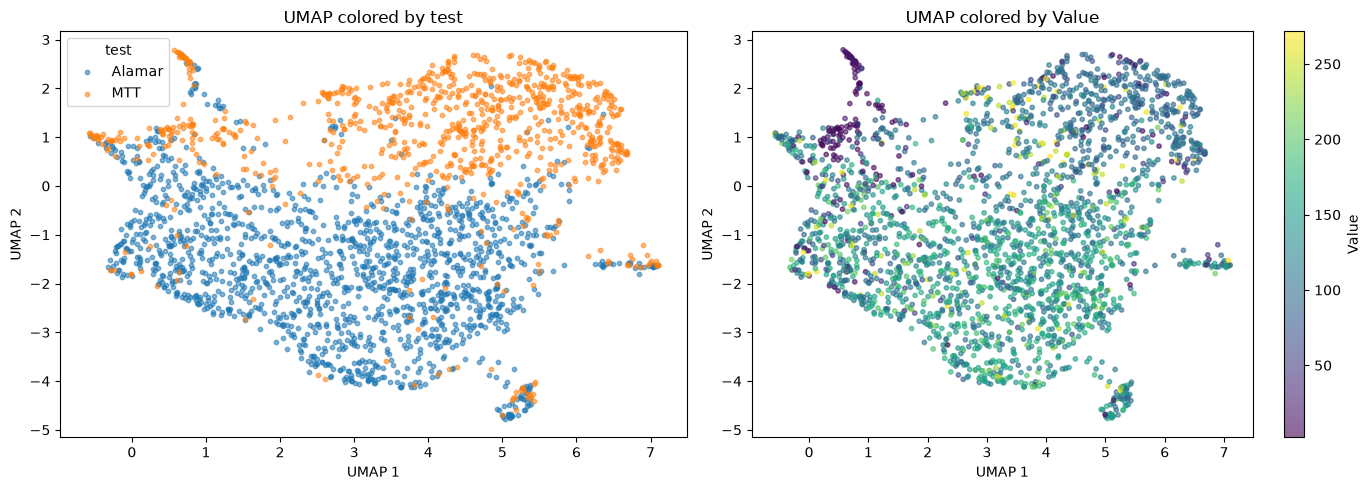

In [111]:
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=RANDOM_STATE,
    n_jobs=1)

X_umap = reducer.fit_transform(X_nonlinear)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label in sorted(np.unique(embedding_test_subset)):
    mask = embedding_test_subset == label
    axes[0].scatter(X_umap[mask, 0], X_umap[mask, 1], s=10, alpha=0.55, label=label)
axes[0].set(xlabel="UMAP 1", ylabel="UMAP 2", title="UMAP colored by test")
axes[0].legend(title="test")
value_plot = axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=embedding_value_subset, cmap="viridis", s=10, alpha=0.6)
axes[1].set(xlabel="UMAP 1", ylabel="UMAP 2", title="UMAP colored by Value")
fig.colorbar(value_plot, ax=axes[1], label="Value")
plt.tight_layout()


### 14.1 UMAP hyperparameters

C:\Users\user\Desktop\kse\practicals\kse-github\.venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:390: RuntimeWarning: ARPACK has failed, falling back to LOBPCG.
  warnings.warn("ARPACK has failed, falling back to LOBPCG.", RuntimeWarning)
C:\Users\user\Desktop\kse\practicals\kse-github\.venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:390: RuntimeWarning: ARPACK has failed, falling back to LOBPCG.
  warnings.warn("ARPACK has failed, falling back to LOBPCG.", RuntimeWarning)
C:\Users\user\Desktop\kse\practicals\kse-github\.venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:390: RuntimeWarning: ARPACK has failed, falling back to LOBPCG.
  warnings.warn("ARPACK has failed, falling back to LOBPCG.", RuntimeWarning)
C:\Users\user\Desktop\kse\practicals\kse-github\.venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:390: RuntimeWarning: ARPACK has failed, falling back to LOBPCG.
  warnings.warn("ARPACK has failed, falling back to LOBPCG.", 

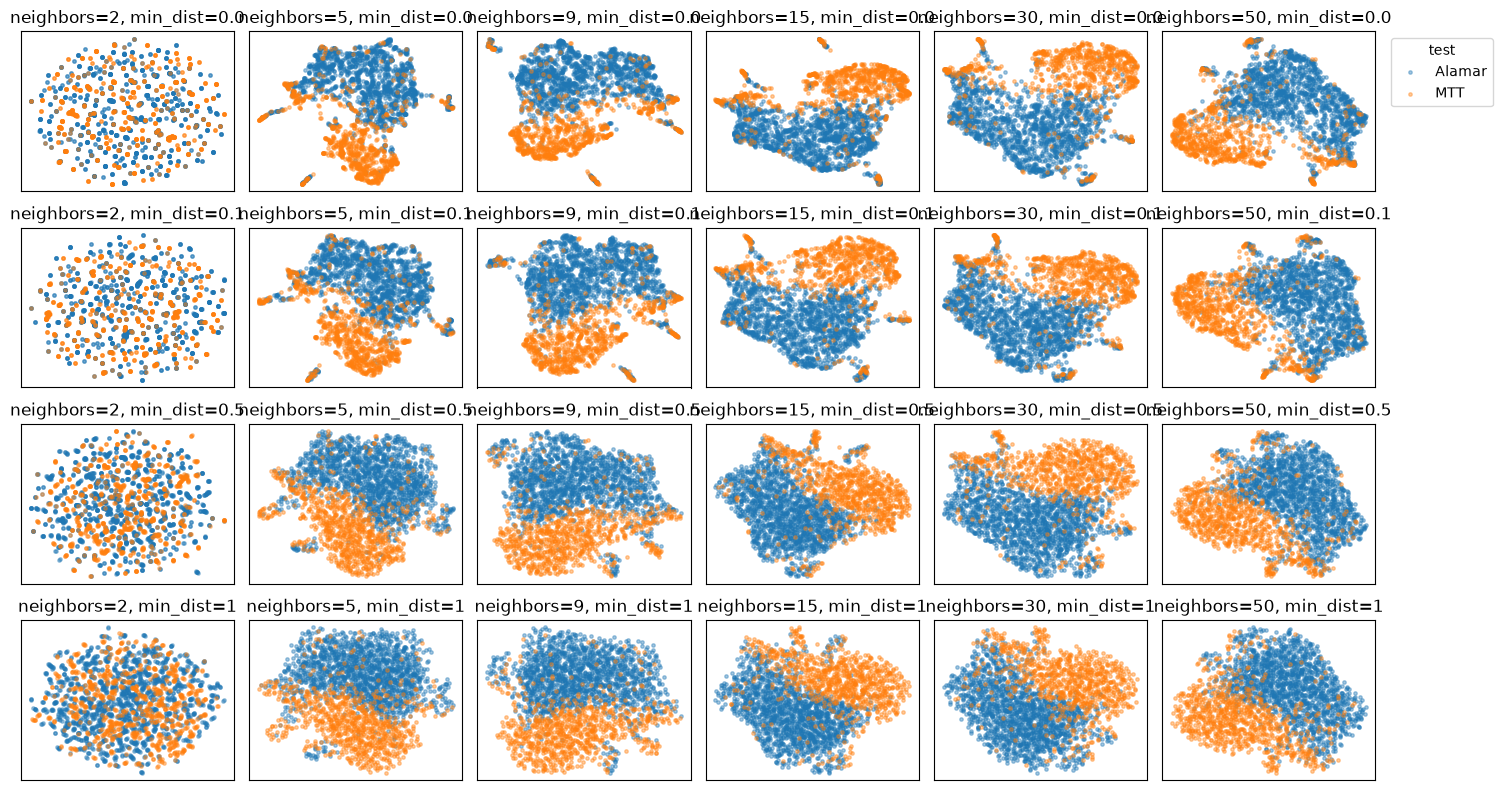

In [112]:
n_neighbors_values = [2, 5, 9, 15, 30, 50]
min_dist_values = [0.0, 0.1, 0.5, 1]
fig, axes = plt.subplots(len(min_dist_values), len(n_neighbors_values), figsize=(15, 8))
for row, min_dist in enumerate(min_dist_values):
    for col, n_neighbors in enumerate(n_neighbors_values):
        embedding = umap.UMAP(
            n_neighbors=n_neighbors, min_dist=min_dist,
            random_state=RANDOM_STATE, n_jobs=1
        ).fit_transform(X_nonlinear)
        ax = axes[row, col]
        for label in sorted(np.unique(embedding_test_subset)):
            mask = embedding_test_subset == label
            ax.scatter(embedding[mask, 0], embedding[mask, 1], s=6, alpha=0.4, label=label)
        ax.set_title(f"neighbors={n_neighbors}, min_dist={min_dist}")
        ax.set_xticks([])
        ax.set_yticks([])
axes[0, -1].legend(title="test", bbox_to_anchor=(1.04, 1), loc="upper left")
plt.tight_layout()


## 16. PCA / t-SNE / UMAP comparison

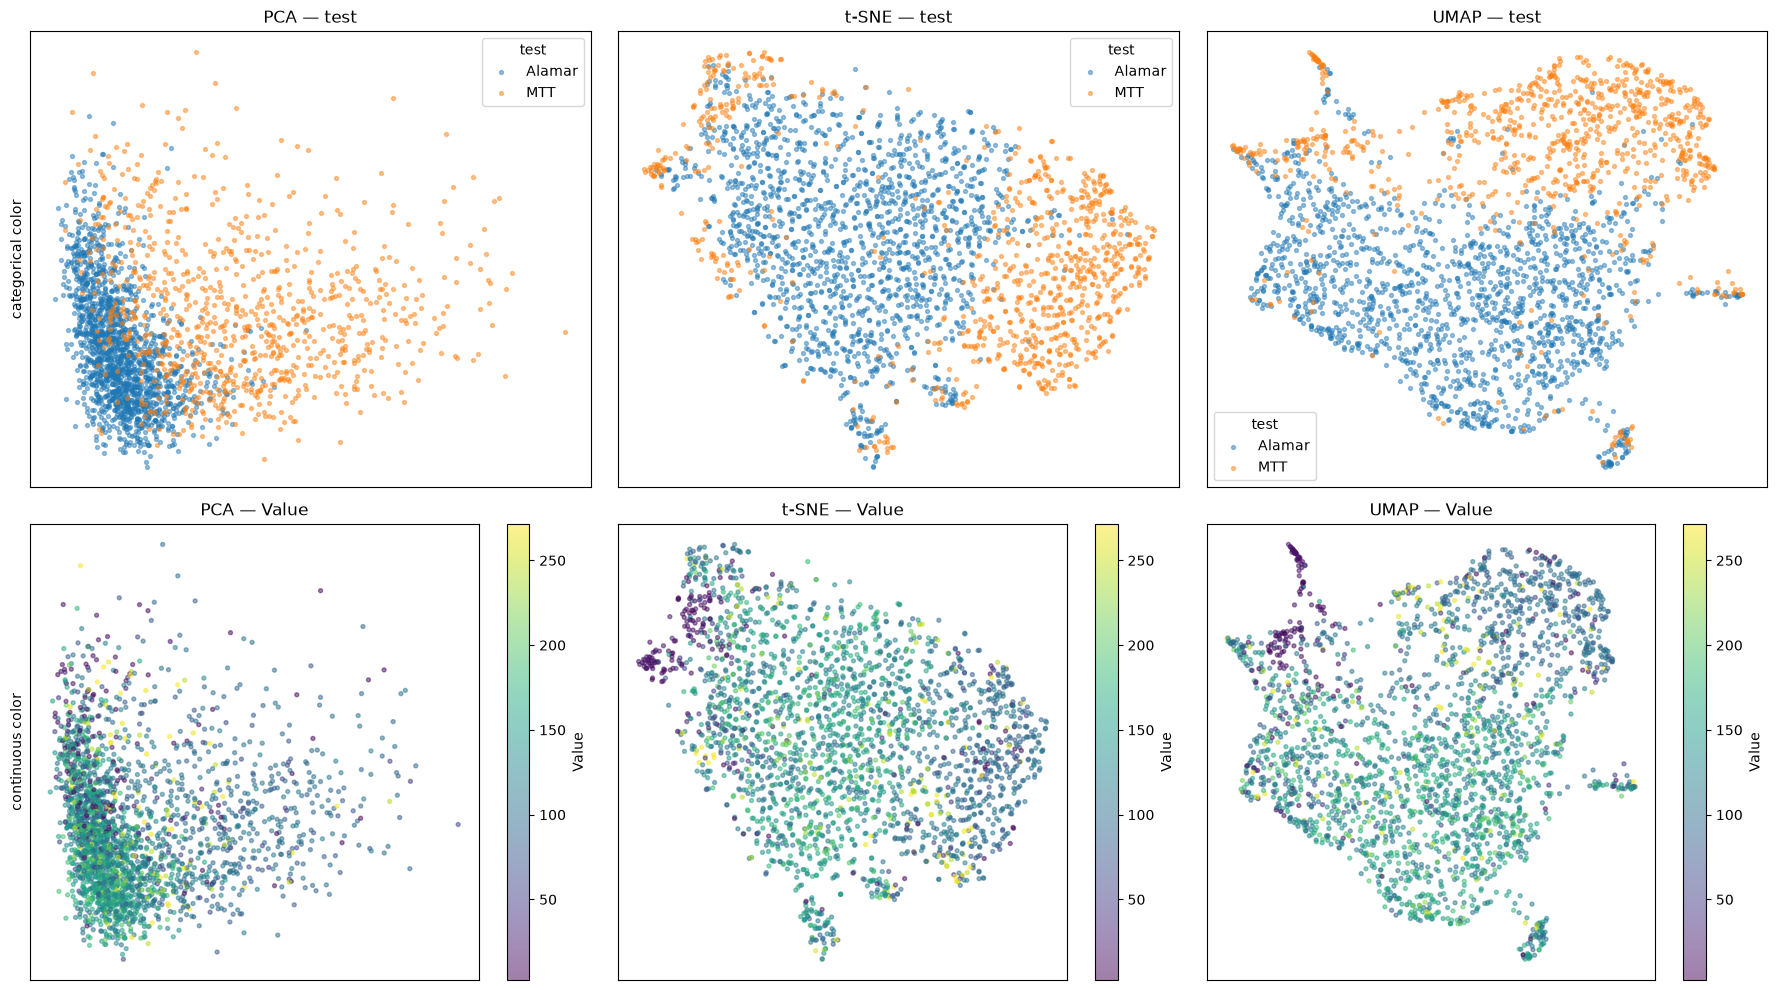

In [113]:
comparison_embeddings = [X_nonlinear[:, :2], X_tsne, X_umap]
comparison_titles = ["PCA", "t-SNE", "UMAP"]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, embedding, title in zip(axes[0], comparison_embeddings, comparison_titles):
    for label in sorted(np.unique(embedding_test_subset)):
        mask = embedding_test_subset == label
        ax.scatter(embedding[mask, 0], embedding[mask, 1], s=8, alpha=0.45, label=label)
    ax.set_title(f"{title} — test")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(title="test")
for ax, embedding, title in zip(axes[1], comparison_embeddings, comparison_titles):
    value_plot = ax.scatter(embedding[:, 0], embedding[:, 1], c=embedding_value_subset, cmap="viridis", s=8, alpha=0.5)
    ax.set_title(f"{title} — Value")
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(value_plot, ax=ax, label="Value")
axes[0, 0].set_ylabel("categorical color")
axes[1, 0].set_ylabel("continuous color")
plt.tight_layout()


| Property | PCA | t-SNE | UMAP |
|---|---|---|---|
| Linear? | Yes | No | No |
| Global structure/variance | Relatively well represented | Not reliably represented | Partly represented, but settings matter |
| Local neighborhoods | Limited by projection | Strong emphasis | Strong emphasis |
| Feature loadings | Available | Not directly available | Not directly available |
| Hyperparameter sensitivity | Low | Perplexity and seed matter | Neighbors and min_dist matter |
| Transform unseen samples | Yes, with a fitted model | Usually not in the basic estimator | Yes, with a fitted reducer |
| Typical bioinformatics role | Variance reduction and inspection | Exploratory local structure | Exploratory structure and visualization |


## 17. Can t-SNE / UMAP feed another model?

Sometimes — but this differs from visualization.

Possible pipeline:

\[
X_{train} \rightarrow embedding \rightarrow classifier
\]

### Cautions
- fit transformations using training data only;
- 2D embeddings intentionally discard/distort information;
- UMAP supports transforming unseen samples after fitting;
- conventional t-SNE is awkward for out-of-sample transformation;
- higher-dimensional embeddings may be more suitable than 2D;
- validate the **whole pipeline** on held-out data.


# Part III — KNN and SVM

## 18. Supervised dataset

**Dataset:** Wisconsin Diagnostic Breast Cance

This dataset contains measurements computed from digitized images of fine-needle aspirate (FNA) samples of breast masses. The prediction target is a diagnosis label. We use it to study distance-based and margin-based classifiers; the goal is methodological, not to build a clinical decision system.

- Samples: 569 nuclei-derived observations
- Features: 30 numeric measurements derived from 10 cell-nucleus descriptors
- Target: malignant or benign diagnosis
- Class balance: 212 malignant and 357 benign observations
- Biological meaning: geometric and texture properties of cell nuclei from an FNA image

KNN classifies a point using nearby training observations. With Euclidean distance,

\[
d(x_i, x_j) = \sqrt{\sum_{r=1}^{p}(x_{ir}-x_{jr})^2}.
\]

An SVM instead learns a decision boundary with a large margin. For a soft-margin linear SVM, the parameter \(C\) controls the trade-off between a wide margin and training violations:

\[
\min_{w,b,\xi} \frac{1}{2}\lVert w\rVert^2 + C\sum_i \xi_i.
\]

We will keep the test set untouched until the final comparison.

In [114]:
breast_cancer = load_breast_cancer()
X = pd.DataFrame(breast_cancer.data, columns=breast_cancer.feature_names)
y = pd.Series(breast_cancer.target, name="diagnosis")
target_names = dict(enumerate(breast_cancer.target_names))
X.shape

(569, 30)

In [115]:
X

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [116]:
y

0      0
1      0
2      0
3      0
4      0
      ..
564    0
565    0
566    0
567    0
568    1
Name: diagnosis, Length: 569, dtype: int64

In [117]:
print("Target labels:", target_names)
display(y.value_counts().rename(index=target_names).to_frame("count"))
display(X.head())


Target labels: {0: np.str_('malignant'), 1: np.str_('benign')}


,count
diagnosis,
benign,357
malignant,212


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 19. Train / validation / test

In [118]:
X_train_valid, X_test, y_train_valid, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

X_train, X_valid, y_train, y_valid = train_test_split(X_train_valid, y_train_valid, test_size=0.25, stratify=y_train_valid, random_state=RANDOM_STATE)

display(y_train.value_counts(normalize=True).rename(index=target_names).to_frame("proportion"))


,proportion
diagnosis,
benign,0.627566
malignant,0.372434


## 20. Why scaling matters

,minimum,maximum,range,standard_deviation
worst area,185.200,4254.00,4068.800,584.017866
mean area,143.500,2501.00,2357.500,349.008764
area error,6.802,542.20,535.398,44.633871
worst perimeter,50.410,251.20,200.790,33.915414
mean perimeter,43.790,186.90,143.110,24.048233
worst texture,12.020,49.54,37.520,6.415130
mean texture,9.710,39.28,29.570,4.498843
worst radius,7.930,36.04,28.110,4.851377
mean radius,6.981,27.42,20.439,3.492031
perimeter error,0.873,18.65,17.777,1.976382


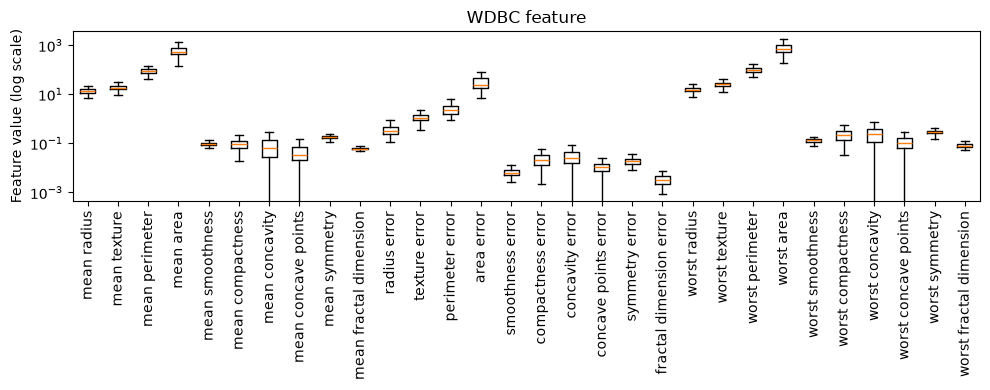

In [119]:
feature_ranges = pd.DataFrame({
    "minimum": X_train.min(),
    "maximum": X_train.max(),
    "range": X_train.max() - X_train.min(),
    "standard_deviation": X_train.std(),
}).sort_values("range", ascending=False)
display(feature_ranges.head(10))

plt.figure(figsize=(10, 4))
plt.boxplot(X_train.to_numpy(), tick_labels=X_train.columns, showfliers=False)
plt.yscale("log")
plt.xticks(rotation=90)
plt.ylabel("Feature value (log scale)")
plt.title("WDBC feature")
plt.tight_layout()
plt.show()


## 21. KNN without scaling

In [120]:
def classifier_metrics(model, X_eval, y_eval):
    predictions = model.predict(X_eval)
    return {
        "accuracy": accuracy_score(y_eval, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_eval, predictions),
        "macro_f1": f1_score(y_eval, predictions, average="macro")}

knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_train, y_train)
raw_knn_metrics = classifier_metrics(knn_raw, X_valid, y_valid)
display(pd.Series(raw_knn_metrics, name="raw KNN").to_frame())


,raw KNN
accuracy,0.929825
balanced_accuracy,0.920734
macro_f1,0.924603


## 22. KNN with scaling

In [121]:
knn = Pipeline([
    ("scale", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))])
knn.fit(X_train, y_train)
scaled_knn_metrics = classifier_metrics(knn, X_valid, y_valid)
display(pd.DataFrame([raw_knn_metrics, scaled_knn_metrics], index=["raw KNN", "scaled KNN"]))


,accuracy,balanced_accuracy,macro_f1
raw KNN,0.929825,0.920734,0.924603
scaled KNN,0.947368,0.939404,0.943452


## 23. Manual selection of k

,k,accuracy,balanced_accuracy,macro_f1
0,1,0.947368,0.939404,0.943452
1,3,0.956140,0.946446,0.952638
2,5,0.947368,0.939404,0.943452
3,7,0.947368,0.939404,0.943452
4,11,0.947368,0.934818,0.942867
5,21,0.947368,0.939404,0.943452


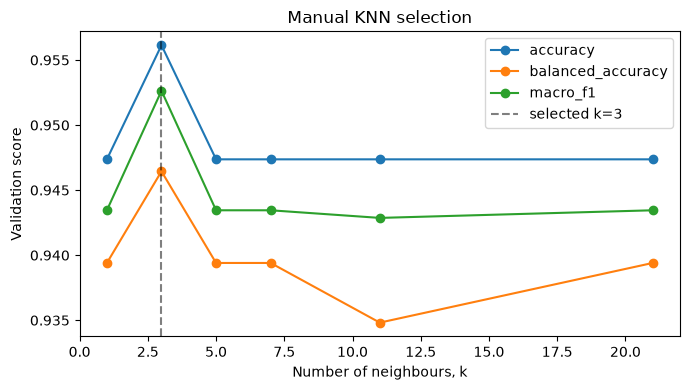

In [122]:
k_values = [1, 3, 5, 7, 11, 21]

knn_results = []
for k in k_values:
    candidate = Pipeline([
        ("scale", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=k))])
    candidate.fit(X_train, y_train)
    metrics = classifier_metrics(candidate, X_valid, y_valid)
    knn_results.append({"k": k, **metrics})

knn_results = pd.DataFrame(knn_results)
display(knn_results)
best_k = int(knn_results.loc[knn_results["macro_f1"].idxmax(), "k"])

plt.figure(figsize=(7, 4))
for metric in ["accuracy", "balanced_accuracy", "macro_f1"]:
    plt.plot(knn_results["k"], knn_results[metric], marker="o", label=metric)
plt.axvline(best_k, color="black", linestyle="--", alpha=0.5, label=f"selected k={best_k}")
plt.xlabel("Number of neighbours, k")
plt.ylabel("Validation score")
plt.title("Manual KNN selection")
plt.legend()
plt.tight_layout()
plt.show()


## 24. Linear SVM

A linear SVM searches for a separating hyperplane. The parameter **C** controls the penalty for observations that are inside the margin or misclassified:

- small **C**: wider margin, more tolerance for training errors;
- large **C**: narrower margin, stronger pressure to fit the training data.

Because the objective uses distances and dot products, scaling belongs inside the pipeline.

In [142]:
svm_linear = Pipeline([
    ("scale", StandardScaler()),
    ("model", SVC(kernel="linear", C=0.01)),
])
svm_linear.fit(X_train, y_train)
linear_svm_metrics = classifier_metrics(svm_linear, X_valid, y_valid)
display(pd.Series(linear_svm_metrics, name="linear SVM").to_frame())


,linear SVM
accuracy,0.964912
balanced_accuracy,0.953488
macro_f1,0.961911


## 25. RBF and polynomial SVM kernels

The radial basis function (RBF) kernel compares observations through their distance:

\[
K_{\mathrm{RBF}}(x_i, x_j) = \exp\left(-\gamma \lVert x_i - x_j \rVert^2\right).
\]

Here **gamma** controls how local the influence of one observation is:

- small **gamma**: smoother, broader influence;
- large **gamma**: very local influence and more flexible boundaries.

The polynomial kernel is

\[
K_{\mathrm{poly}}(x_i, x_j) = \left(\gamma x_i^{\mathsf{T}}x_j + r\right)^d,
\]

where \(d\) is the polynomial degree and \(r\) is the intercept term (`coef0` in scikit-learn).

The next illustration uses two-dimensional representations only to make decision boundaries visible. The final comparison trains each model on the complete feature set.

In [145]:
svm_rbf = Pipeline([
    ("scale", StandardScaler()),
    ("model", SVC(kernel="rbf", C=1, gamma=0.01)),
])
svm_rbf.fit(X_train, y_train)
rbf_svm_metrics = classifier_metrics(svm_rbf, X_valid, y_valid)
display(pd.Series(rbf_svm_metrics, name="RBF SVM").to_frame())


,RBF SVM
accuracy,0.956140
balanced_accuracy,0.946446
macro_f1,0.952638


In [149]:
poly_rbf = Pipeline([
    ("scale", StandardScaler()),
    ("model", SVC(kernel="poly", C=10, degree=3)),
])
poly_rbf.fit(X_train, y_train)
poly_svm_metrics = classifier_metrics(poly_rbf, X_valid, y_valid)
display(pd.Series(poly_svm_metrics, name="Poly SVM").to_frame())

,Poly SVM
accuracy,0.938596
balanced_accuracy,0.918605
macro_f1,0.932206


## 26. Visual illustration of the SVM kernels

To draw a decision boundary, we temporarily represent the training observations with two coordinates. PCA is a linear representation. The classifiers are trained on the displayed two-dimensional coordinates, so these plots are not the final performance evaluation.

We compare three kernels: linear, polynomial, and RBF.

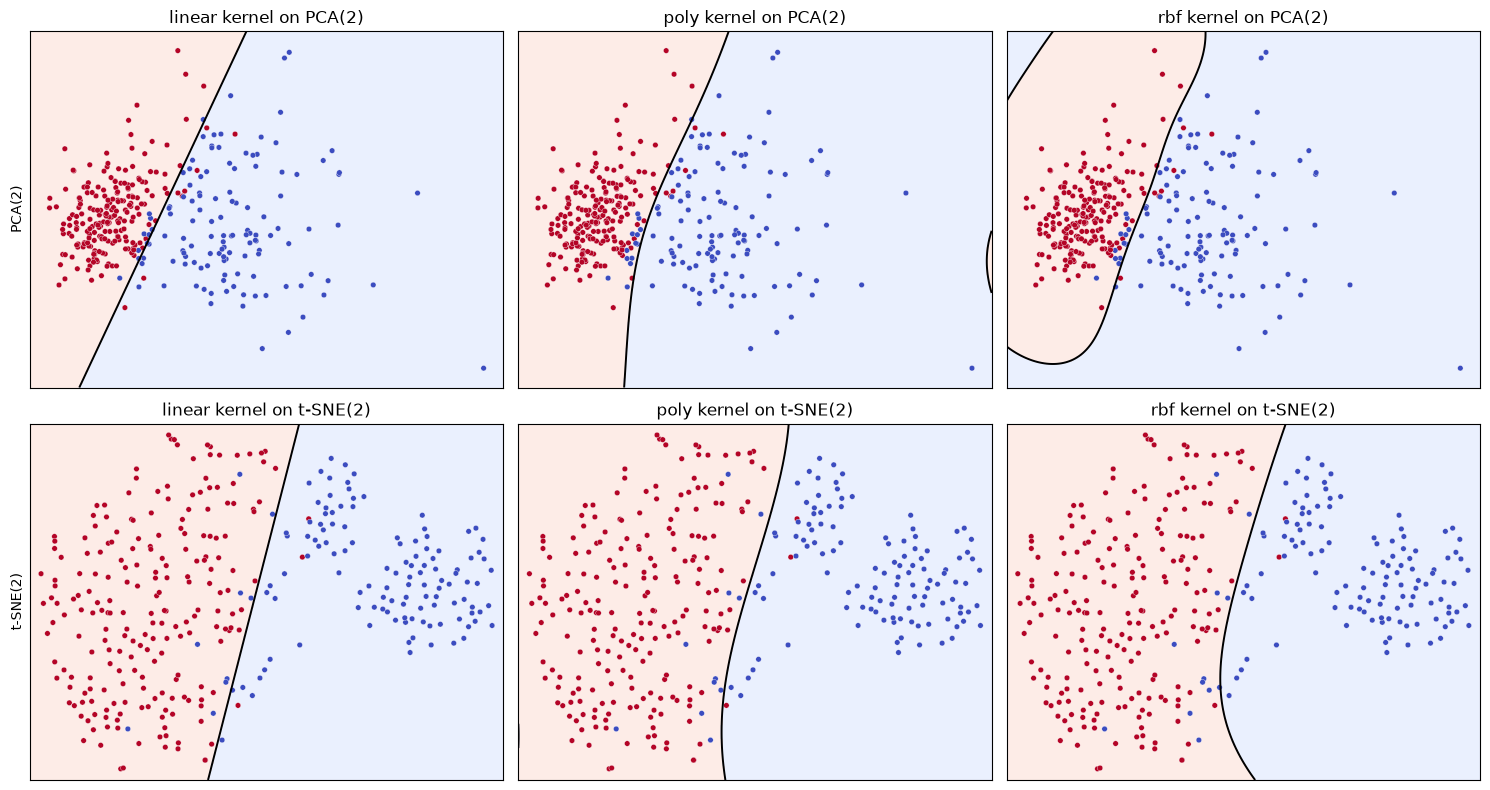

In [125]:
X_train_numeric = X_train.to_numpy(dtype=float)
y_train_numeric = y_train.to_numpy()
visual_scaler = StandardScaler()
X_train_scaled_for_visualization = visual_scaler.fit_transform(X_train_numeric)

visual_pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca2 = visual_pca.fit_transform(X_train_scaled_for_visualization)
visual_tsne = TSNE(n_components=2, perplexity=30, init="pca", learning_rate="auto", max_iter=750, random_state=RANDOM_STATE)
X_train_tsne2 = visual_tsne.fit_transform(X_train_scaled_for_visualization)

def plot_svm_boundary(ax, X_2d, y_2d, kernel, title):
    parameters = {"kernel": kernel, "C": 1, "gamma": "scale"}
    if kernel == "poly":
        parameters.update({"degree": 3, "coef0": 1})
    model = SVC(**parameters)
    model.fit(X_2d, y_2d)
    x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
    y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))
    grid = np.c_[xx.ravel(), yy.ravel()]
    decision = model.decision_function(grid).reshape(xx.shape)
    ax.contourf(xx, yy, decision > 0, alpha=0.18, cmap="coolwarm")
    ax.contour(xx, yy, decision, levels=[0], colors="black", linewidths=1.4)
    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap="coolwarm", s=16, edgecolor="white", linewidth=0.25)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

kernels = ["linear", "poly", "rbf"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for column, kernel in enumerate(kernels):
    plot_svm_boundary(axes[0, column], X_train_pca2, y_train_numeric, kernel, f"{kernel} kernel on PCA(2)")
    plot_svm_boundary(axes[1, column], X_train_tsne2, y_train_numeric, kernel, f"{kernel} kernel on t-SNE(2)")
axes[0, 0].set_ylabel("PCA(2)")
axes[1, 0].set_ylabel("t-SNE(2)")
plt.tight_layout()


## 27. Manual SVM hyperparameter comparison

,C,gamma,accuracy,balanced_accuracy,macro_f1
15,100.0,scale,0.973684,0.969702,0.971863
17,100.0,0.01,0.973684,0.969702,0.971863
10,10.0,scale,0.973684,0.969702,0.971863
16,100.0,0.001,0.964912,0.958074,0.962302
12,10.0,0.01,0.964912,0.958074,0.962302
11,10.0,0.001,0.964912,0.953488,0.961911
5,1.0,scale,0.956140,0.951032,0.953106
7,1.0,0.01,0.956140,0.946446,0.952638
6,1.0,0.001,0.956140,0.941860,0.952129
18,100.0,0.1,0.947368,0.948575,0.944481


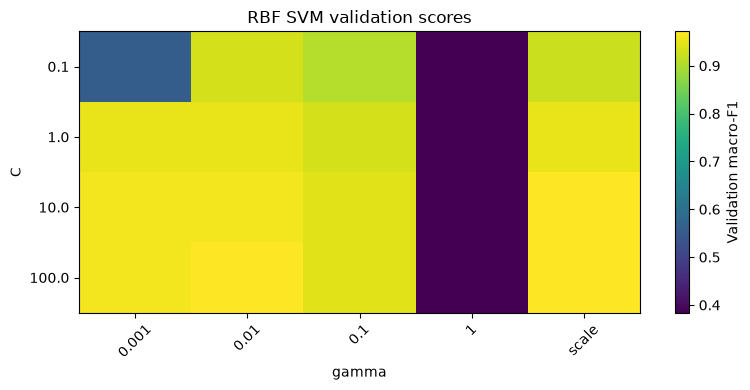

In [150]:
C_values = [0.1, 1, 10, 100]
gamma_values = ["scale", 0.001, 0.01, 0.1, 1]

svm_validation_results = []
for C in C_values:
    for gamma in gamma_values:
        candidate = Pipeline([
            ("scale", StandardScaler()),
            ("model", SVC(kernel="rbf", C=C, gamma=gamma)),
        ])
        candidate.fit(X_train, y_train)
        metrics = classifier_metrics(candidate, X_valid, y_valid)
        svm_validation_results.append({"C": C, "gamma": str(gamma), **metrics})

svm_validation_results = pd.DataFrame(svm_validation_results)
display(svm_validation_results.sort_values("macro_f1", ascending=False).head(10))
best_svm_row = svm_validation_results.loc[svm_validation_results["macro_f1"].idxmax()]
best_svm_C = float(best_svm_row["C"])
best_svm_gamma = best_svm_row["gamma"]
if best_svm_gamma not in {"scale", "auto"}:
    best_svm_gamma = float(best_svm_gamma)

score_grid = svm_validation_results.pivot(index="C", columns="gamma", values="macro_f1")
plt.figure(figsize=(8, 4))
plt.imshow(score_grid, aspect="auto", cmap="viridis", vmin=score_grid.min().min(), vmax=score_grid.max().max())
plt.colorbar(label="Validation macro-F1")
plt.xticks(range(len(score_grid.columns)), score_grid.columns, rotation=45)
plt.yticks(range(len(score_grid.index)), score_grid.index)
plt.xlabel("gamma")
plt.ylabel("C")
plt.title("RBF SVM validation scores")
plt.tight_layout()
plt.show()


## 28. PCA inside a supervised pipeline

### Leakage-prone
```python
X_scaled = scaler.fit_transform(X)
X_pca = PCA(20).fit_transform(X_scaled)
X_train, X_test = train_test_split(X_pca)
```

PCA has already seen test observations.

### Correct
Fit scaling and PCA **inside the training pipeline**.


In [151]:
svm_pca = Pipeline([
    ("scale", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("model", SVC(kernel="rbf", C=best_svm_C, gamma=best_svm_gamma)),
])
svm_pca.fit(X_train, y_train)
pca_svm_metrics = classifier_metrics(svm_pca, X_valid, y_valid)
print("Number of PCA components retained:", svm_pca.named_steps["pca"].n_components_)
display(pd.Series(pca_svm_metrics, name="PCA + RBF SVM").to_frame())


Number of PCA components retained: 10


,PCA + RBF SVM
accuracy,0.964912
balanced_accuracy,0.962660
macro_f1,0.962660


## 29. Compare KNN and SVM

,model,n_features,accuracy,balanced_accuracy,macro_f1
0,polynomial SVM,30,0.973684,0.969246,0.971583
1,scaled KNN,30,0.973684,0.964286,0.971277
2,linear SVM,30,0.964912,0.962302,0.962302
3,RBF SVM,30,0.956140,0.955357,0.953106
4,PCA + RBF SVM,10,0.947368,0.943452,0.943452
5,raw KNN,30,0.929825,0.914683,0.922973


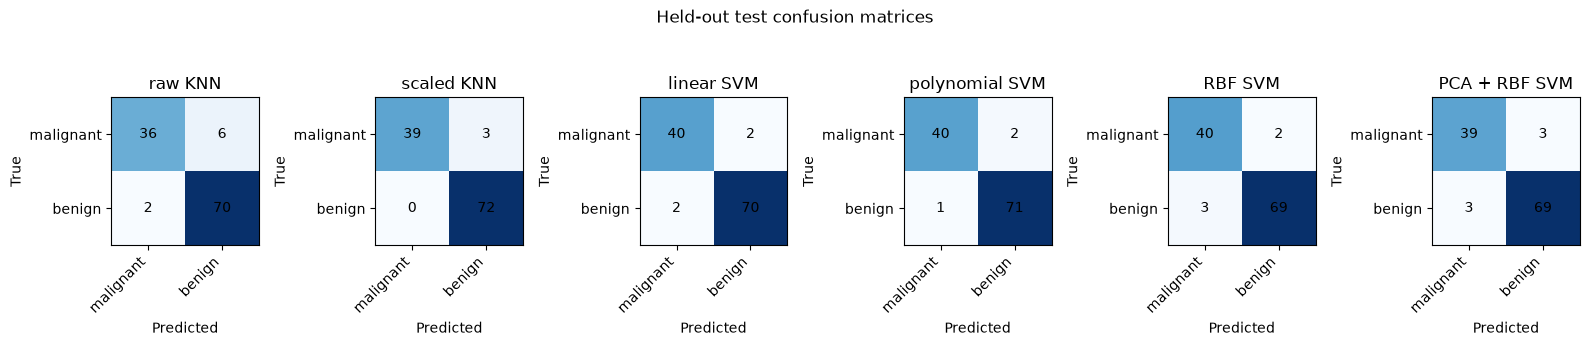

In [152]:
models = {
    "raw KNN": KNeighborsClassifier(n_neighbors=best_k),
    "scaled KNN": Pipeline([
        ("scale", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=best_k)),
    ]),
    "linear SVM": Pipeline([
        ("scale", StandardScaler()),
        ("model", SVC(kernel="linear", C=1)),
    ]),
    "polynomial SVM": Pipeline([
        ("scale", StandardScaler()),
        ("model", SVC(kernel="poly", degree=3, C=1, gamma="scale", coef0=1)),
    ]),
    "RBF SVM": Pipeline([
        ("scale", StandardScaler()),
        ("model", SVC(kernel="rbf", C=best_svm_C, gamma=best_svm_gamma)),
    ]),
    "PCA + RBF SVM": Pipeline([
        ("scale", StandardScaler()),
        ("pca", PCA(n_components=0.95)),
        ("model", SVC(kernel="rbf", C=best_svm_C, gamma=best_svm_gamma)),
    ]),
}

test_results = []
test_predictions = {}
for name, model in models.items():
    model.fit(X_train_valid, y_train_valid)
    predictions = model.predict(X_test)
    test_predictions[name] = predictions
    row = {
        "model": name,
        "n_features": model.named_steps["pca"].n_components_ if hasattr(model, "named_steps") and "pca" in model.named_steps else X_train_valid.shape[1],
        "accuracy": accuracy_score(y_test, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_test, predictions),
        "macro_f1": f1_score(y_test, predictions, average="macro"),
    }
    test_results.append(row)

test_results = pd.DataFrame(test_results).sort_values("macro_f1", ascending=False)
display(test_results.reset_index(drop=True))

fig, axes = plt.subplots(1, len(models), figsize=(16, 3.5))
for ax, (name, predictions) in zip(axes, test_predictions.items()):
    cm = confusion_matrix(y_test, predictions, labels=[0, 1])
    ax.imshow(cm, cmap="Blues")
    ax.set_title(name)
    ax.set_xticks([0, 1], [target_names[0], target_names[1]], rotation=45, ha="right")
    ax.set_yticks([0, 1], [target_names[0], target_names[1]])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    for (row, col), value in np.ndenumerate(cm):
        ax.text(col, row, value, ha="center", va="center")
fig.suptitle("Held-out test confusion matrices")
plt.tight_layout()
plt.show()


# Part IV — Clustering microscopy data

## 30. Microscopy dataset
**Dataset:** the same VGG16 embeddings extracted from microscopy cell crops as in Part II.

 We reuse its loaded metadata and already standardized feature matrix rather than re-importing or scaling the data a second time. Clustering uses only the VGG representation; `Value` and `test` remain external variables for interpretation.


In [153]:
vgg_columns = [column for column in microscopy.columns if column.startswith("vgg_")]
metadata_columns = ["crop_path", "filename", "cell_id", "image_path", "mask_path", "Value", "test"]

display(microscopy[metadata_columns].head())
display(microscopy["test"].value_counts().to_frame("count"))
display(microscopy["Value"].describe().to_frame("Value"))


,crop_path,filename,cell_id,image_path,mask_path,Value,test
0,seg_results\derived\crops\01082025_CTDX014_C9_...,01082025_CTDX014_C9.tif,722.0,seg_results\overlays\01082025_CTDX014_C9_overl...,seg_results\masks\01082025_CTDX014_C9_mask.tiff,138.5,Alamar
1,seg_results\derived\crops\01082025_CTDX015_C3_...,01082025_CTDX015_C3.tif,473.0,seg_results\overlays\01082025_CTDX015_C3_overl...,seg_results\masks\01082025_CTDX015_C3_mask.tiff,97.5,Alamar
2,seg_results\derived\crops\01082025_CTDX014_E3_...,01082025_CTDX014_E3.tif,220.0,seg_results\overlays\01082025_CTDX014_E3_overl...,seg_results\masks\01082025_CTDX014_E3_mask.tiff,192.9,Alamar
3,seg_results\derived\crops\01082025_CTDX014_G11...,01082025_CTDX014_G11.tif,83.0,seg_results\overlays\01082025_CTDX014_G11_over...,seg_results\masks\01082025_CTDX014_G11_mask.tiff,178.6,Alamar
4,seg_results\derived\crops\01082025_CTDX014_G11...,01082025_CTDX014_G11.tif,461.0,seg_results\overlays\01082025_CTDX014_G11_over...,seg_results\masks\01082025_CTDX014_G11_mask.tiff,178.6,Alamar


,count
test,
Alamar,17278
MTT,9774


,Value
count,27052.000000
mean,124.874407
std,56.412262
min,2.454000
25%,96.330000
50%,116.600000
75%,161.100000
max,271.664444


In [154]:

X_micro = pd.DataFrame(X_embedding_scaled, columns=vgg_columns)
X_micro_scaled = X_embedding_scaled.astype(np.float32)
y_known = pd.Series(embedding_test, name="test")
value_known = pd.Series(embedding_value, name="Value")
print("Missing scaled features:", int(np.isnan(X_micro_scaled).sum()))

Missing scaled features: 0


## 31. Inspect and preprocess microscopy features

VGG embeddings are already learned image representations, but their feature scales and sparsity still affect Euclidean methods such as K-means. We standardize the features before PCA. The metadata columns remain outside `X_micro`.

In [155]:
X_micro_scaled.shape


(27052, 512)

## 32. PCA before clustering

Clustering directly in 512 dimensions is possible but expensive and can be dominated by noisy directions. We first create a 30-dimensional PCA representation.

PCA representation: (27052, 250)
Variance explained by 100 PCs: 0.865


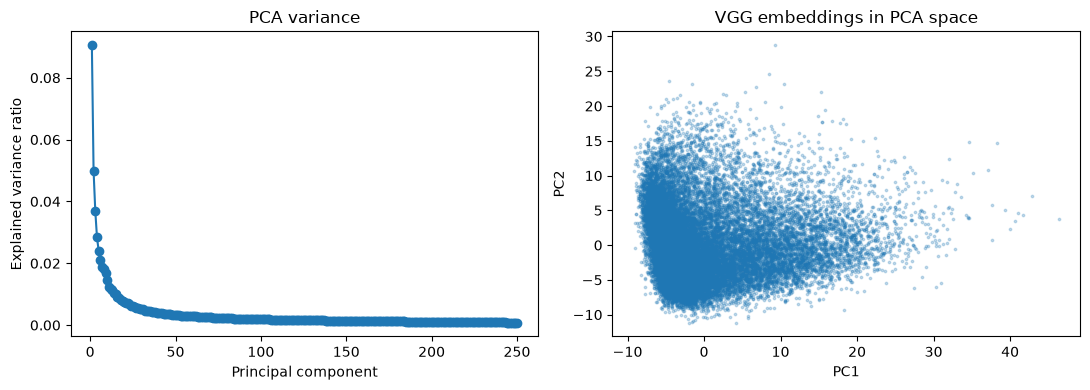

In [166]:
pca_micro = PCA(n_components=250, svd_solver="randomized", random_state=RANDOM_STATE)
X_micro_pca = pca_micro.fit_transform(X_micro_scaled).astype(np.float32)

print("PCA representation:", X_micro_pca.shape)
print("Variance explained by 100 PCs:", round(pca_micro.explained_variance_ratio_.sum(), 3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(np.arange(1, 251), pca_micro.explained_variance_ratio_, marker="o")
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Explained variance ratio")
axes[0].set_title("PCA variance")
axes[1].scatter(X_micro_pca[:, 0], X_micro_pca[:, 1], s=3, alpha=0.25)
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].set_title("VGG embeddings in PCA space")
plt.tight_layout()
plt.show()


### Representation choice
Should clustering use:
- standardized original features;
- selected features;
- PCA scores?


## 33. K-means

K-means partitions observations by assigning each point to the nearest centroid and then updating the centroids. It requires us to choose the number of clusters, \(K\), in advance.

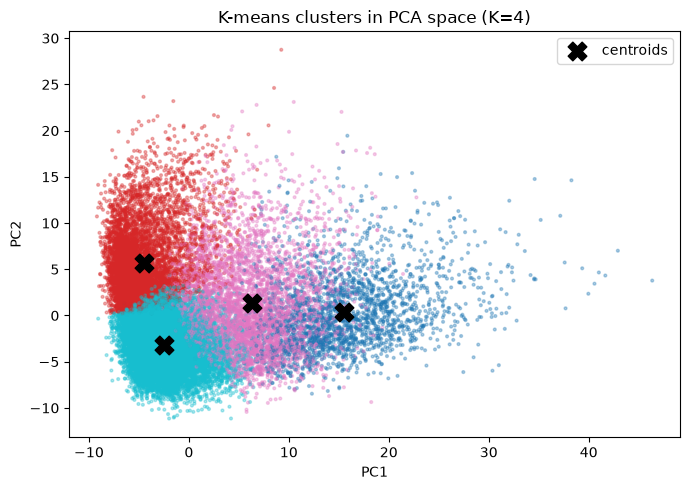

In [167]:
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=RANDOM_STATE)
cluster_labels = kmeans.fit_predict(X_micro_pca)

plt.figure(figsize=(7, 5))
plt.scatter(X_micro_pca[:, 0], X_micro_pca[:, 1], c=cluster_labels, cmap="tab10", s=4, alpha=0.35)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker="X", s=180, c="black", label="centroids")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"K-means clusters in PCA space (K={n_clusters})")
plt.legend()
plt.tight_layout()
plt.show()


## 34. Choosing K

The elbow plot shows within-cluster sum of squares (inertia). Silhouette score compares within-cluster cohesion with separation from the nearest alternative cluster. Neither is a substitute for biological interpretation.

In [168]:
k_values = range(2, 9)
inertias = []
silhouettes = []
for k in k_values:
    candidate = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = candidate.fit_predict(X_micro_pca)
    inertias.append(candidate.inertia_)
    silhouettes.append(silhouette_score(X_micro_pca, labels, sample_size=min(5000, len(X_micro_pca)), random_state=RANDOM_STATE))

cluster_diagnostics = pd.DataFrame({"K": list(k_values), "inertia": inertias, "silhouette": silhouettes})
display(cluster_diagnostics)
selected_k = int(cluster_diagnostics.loc[cluster_diagnostics["silhouette"].idxmax(), "K"])
print("Selected K from the largest silhouette score:", selected_k)


,K,inertia,silhouette
0,2,11073112.0,0.231362
1,3,10666222.0,0.040256
2,4,10462850.0,0.037658
3,5,10287426.0,0.002748
4,6,10135173.0,-0.001370
5,7,9993588.0,-0.005821
6,8,9879482.0,-0.002417


Selected K from the largest silhouette score: 2


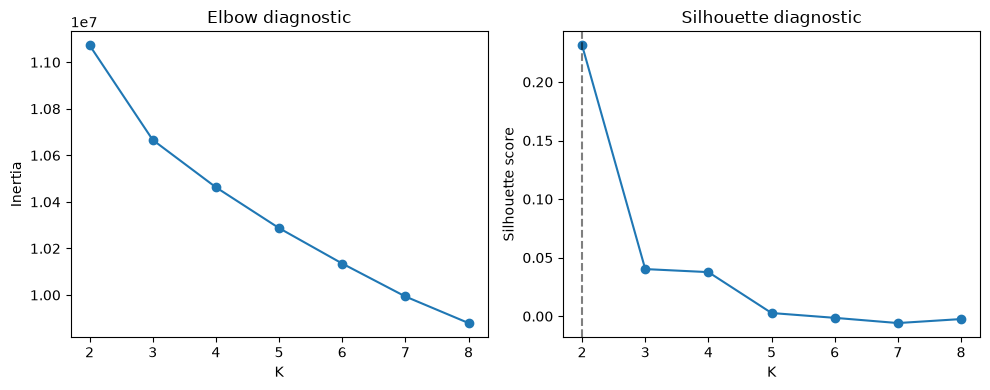

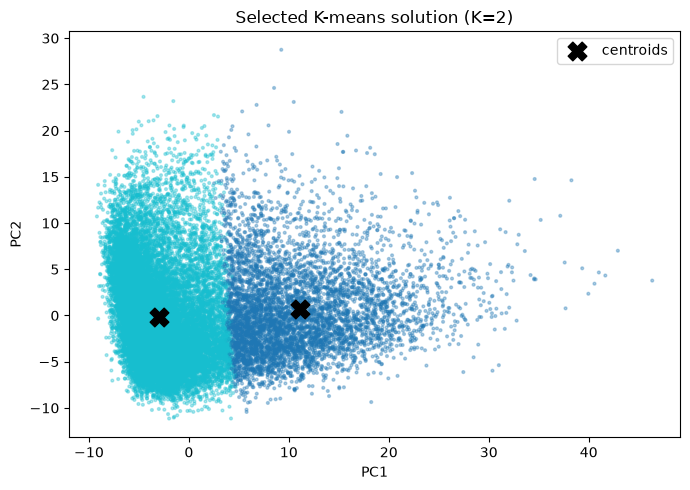

In [169]:

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(cluster_diagnostics["K"], cluster_diagnostics["inertia"], marker="o")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow diagnostic")
axes[1].plot(cluster_diagnostics["K"], cluster_diagnostics["silhouette"], marker="o")
axes[1].axvline(selected_k, color="black", linestyle="--", alpha=0.5)
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette diagnostic")
plt.tight_layout()
plt.show()

# Refit K-means using the selected value before external comparison.
kmeans = KMeans(n_clusters=selected_k, n_init=10, random_state=RANDOM_STATE)
cluster_labels = kmeans.fit_predict(X_micro_pca)

# Inspect the clustering produced by the selected K.
plt.figure(figsize=(7, 5))
plt.scatter(X_micro_pca[:, 0], X_micro_pca[:, 1], c=cluster_labels, cmap="tab10", s=4, alpha=0.35)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker="X", s=180, c="black", label="centroids")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Selected K-means solution (K={selected_k})")
plt.legend()
plt.tight_layout()
plt.show()


## 35. Hierarchical clustering

Agglomerative clustering builds a hierarchy by repeatedly merging similar observations. It can be computationally expensive for tens of thousands of cells, so here we use a deterministic subset for illustration.

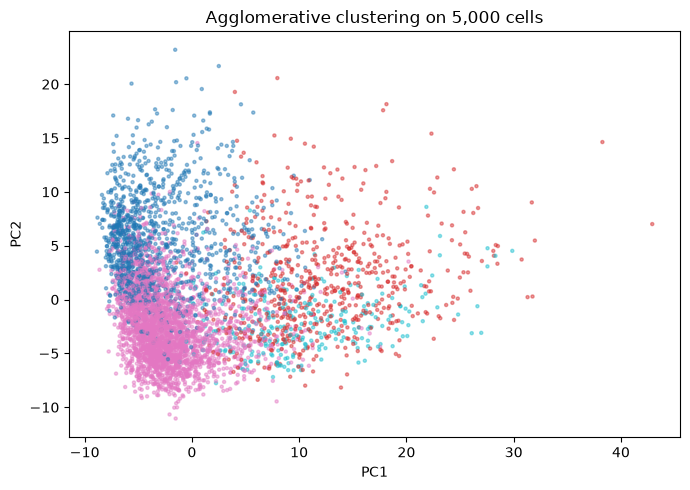

In [170]:
hierarchical_size = 5000
hierarchical_indices = np.random.default_rng(RANDOM_STATE).choice(len(X_micro_pca), size=hierarchical_size, replace=False)
hierarchical_model = AgglomerativeClustering(n_clusters=4, linkage="ward")
hierarchical_labels = hierarchical_model.fit_predict(X_micro_pca[hierarchical_indices])

plt.figure(figsize=(7, 5))
plt.scatter(X_micro_pca[hierarchical_indices, 0], X_micro_pca[hierarchical_indices, 1], c=hierarchical_labels, cmap="tab10", s=5, alpha=0.45)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Agglomerative clustering on {hierarchical_size:,} cells")
plt.tight_layout()
plt.show()


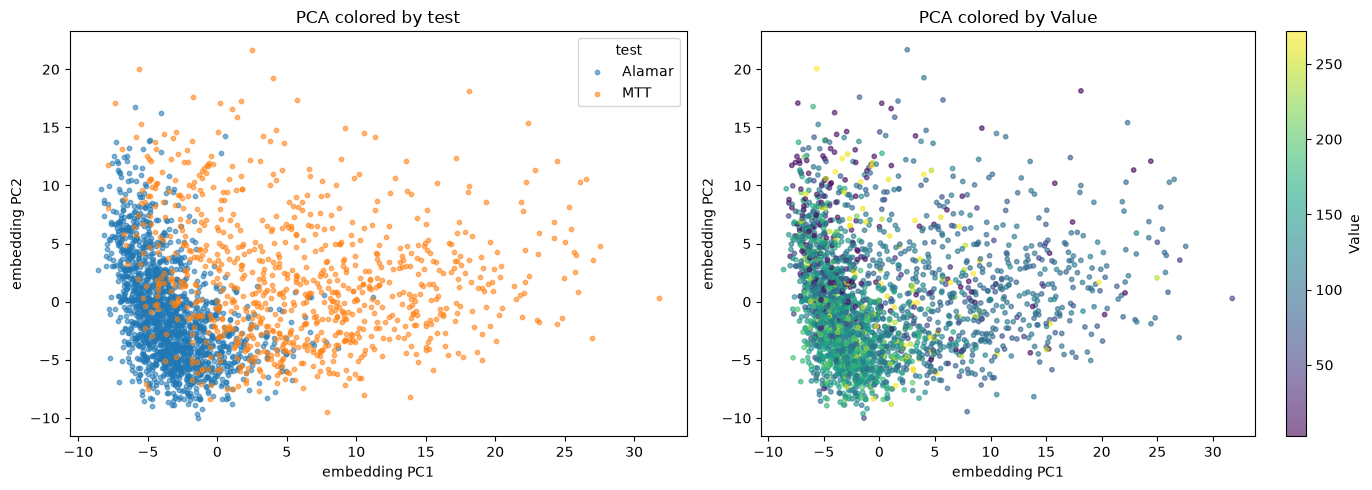

In [163]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label in sorted(np.unique(embedding_test_subset)):
    mask = embedding_test_subset == label
    axes[0].scatter(X_nonlinear[mask, 0], X_nonlinear[mask, 1], s=10, alpha=0.55, label=label)
axes[0].set(xlabel="embedding PC1", ylabel="embedding PC2", title="PCA colored by test")
axes[0].legend(title="test")
value_plot = axes[1].scatter(X_nonlinear[:, 0], X_nonlinear[:, 1], c=embedding_value_subset, cmap="viridis", s=10, alpha=0.6)
axes[1].set(xlabel="embedding PC1", ylabel="embedding PC2", title="PCA colored by Value")
fig.colorbar(value_plot, ax=axes[1], label="Value")
plt.tight_layout()


## 36. DBSCAN

DBSCAN groups dense regions and marks isolated observations as noise. It does not require a preselected number of clusters, but `eps` and `min_samples` strongly affect the result.

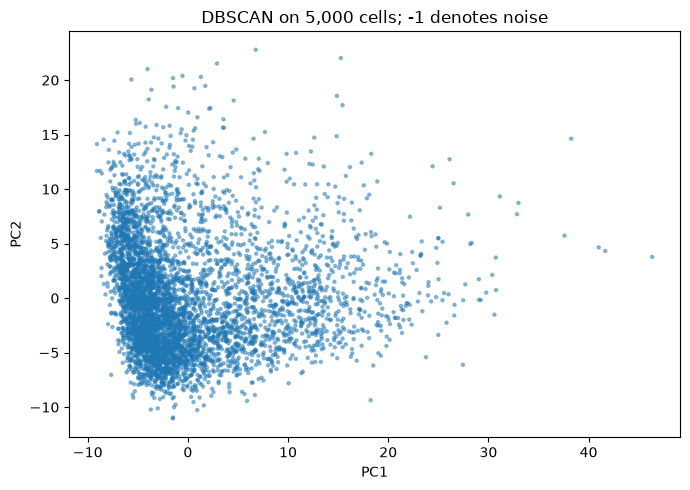

DBSCAN noise fraction: 1.0


In [171]:
dbscan_size = 5000
dbscan_indices = np.random.default_rng(RANDOM_STATE + 1).choice(len(X_micro_pca), size=dbscan_size, replace=False)
dbscan = DBSCAN(eps=10.0, min_samples=15, n_jobs=-1)
dbscan_labels = dbscan.fit_predict(X_micro_pca[dbscan_indices])

plt.figure(figsize=(7, 5))
plt.scatter(X_micro_pca[dbscan_indices, 0], X_micro_pca[dbscan_indices, 1], c=dbscan_labels, cmap="tab20", s=5, alpha=0.45)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"DBSCAN on {dbscan_size:,} cells; -1 denotes noise")
plt.tight_layout()
plt.show()
print("DBSCAN noise fraction:", round(float((dbscan_labels == -1).mean()), 3))


## 37. Compare clusters with external measurements

The clustering did not use `test` or `Value`. We can therefore compare the selected clusters with both variables after fitting. `test` is categorical, so a direct crosstab is appropriate. `Value` is continuous, so we show its distribution by cluster and create a teaching crosstab after dividing it into quartiles.


Test counts by cluster:


test,Alamar,MTT
cluster,,
0,180,5559
1,17098,4215


Test proportions within each cluster:


test,Alamar,MTT
cluster,,
0,0.031,0.969
1,0.802,0.198


Value-quartile counts by cluster:


Value_quartile,Q1 low,Q2,Q3,Q4 high
cluster,,,,
0,2600,2124,654,361
1,4194,4699,6042,6378


Value-quartile proportions within each cluster:


Value_quartile,Q1 low,Q2,Q3,Q4 high
cluster,,,,
0,0.453,0.37,0.114,0.063
1,0.197,0.22,0.283,0.299


,count,mean,median,std
cluster,,,,
0,5739,103.868511,99.930000,45.905133
1,21313,130.530713,128.287778,57.629190


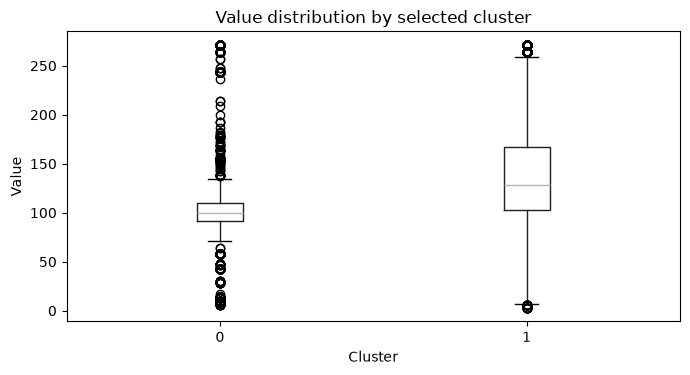

In [172]:
cluster_comparison = pd.DataFrame({
    "cluster": cluster_labels,
    "test": y_known.to_numpy(),
    "Value": value_known.to_numpy(),
})

print("Test counts by cluster:")
display(pd.crosstab(cluster_comparison["cluster"], cluster_comparison["test"]))
print("Test proportions within each cluster:")
display(pd.crosstab(cluster_comparison["cluster"], cluster_comparison["test"], normalize="index").round(3))

cluster_comparison["Value_quartile"] = pd.qcut(
    cluster_comparison["Value"], q=4, labels=["Q1 low", "Q2", "Q3", "Q4 high"]
)
print("Value-quartile counts by cluster:")
display(pd.crosstab(cluster_comparison["cluster"], cluster_comparison["Value_quartile"]))
print("Value-quartile proportions within each cluster:")
display(pd.crosstab(cluster_comparison["cluster"], cluster_comparison["Value_quartile"], normalize="index").round(3))
display(cluster_comparison.groupby("cluster")["Value"].agg(["count", "mean", "median", "std"]))

fig, ax = plt.subplots(figsize=(7, 4))
cluster_comparison.boxplot(column="Value", by="cluster", ax=ax, grid=False)
ax.set_title("Value distribution by selected cluster")
ax.set_xlabel("Cluster")
ax.set_ylabel("Value")
plt.suptitle("")
plt.tight_layout()


In [3]:
microscopy_home_task = pd.read_csv("all_sources_isc_vgg_embeddings.tar.gz", compression="gzip")

In [177]:
microscopy_home_task

,source,label,Value,vgg_0,vgg_1,vgg_2,vgg_3,vgg_4,vgg_5,vgg_6,...,vgg_502,vgg_503,vgg_504,vgg_505,vgg_506,vgg_507,vgg_508,vgg_509,vgg_510,vgg_511
0,mtt,C,94.774444,0.011359,0.241203,0.344854,0.000000,11.211005,0.004637,0.0,...,0.188881,0.0,0.954637,2.482550,0.000000,0.118003,0.000000,0.000000,1.703285,0.000000
1,mtt,C,94.774444,0.025853,0.000000,1.069848,0.000000,11.320415,0.000000,0.0,...,0.000000,0.0,0.168406,6.162180,0.000000,0.107752,0.000000,0.271620,4.474264,0.000000
2,mtt,C,94.774444,0.480963,0.000000,3.107252,0.000000,4.831994,0.064862,0.0,...,0.124030,0.0,0.665731,1.306546,0.030879,0.144269,0.005907,0.232978,1.154307,0.000000
3,mtt,C,94.774444,0.000000,0.000000,0.058814,0.000000,6.624664,0.000000,0.0,...,0.316281,0.0,0.318968,0.330109,0.480029,0.542135,0.000000,0.008872,3.581180,0.289227
4,mtt,C,94.774444,0.000000,0.000000,0.119758,0.000000,8.961069,0.000000,0.0,...,0.099849,0.0,0.034700,1.626213,0.012560,0.605835,0.000000,0.025230,1.533522,0.180085
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23840,study18,S,NaN,0.059749,0.000000,0.000000,0.312913,0.053099,0.000000,0.0,...,0.198128,0.0,0.024524,0.771849,0.000000,0.002295,0.000000,0.000000,0.800087,0.000000
23841,study18,S,NaN,0.000000,0.000000,1.000184,0.000000,0.740112,0.000000,0.0,...,0.434452,0.0,0.000000,0.732429,0.000000,0.662563,0.000000,0.000000,0.678243,0.000000
23842,study18,S,NaN,0.000000,0.000000,0.677755,0.000000,2.872867,0.000000,0.0,...,2.191196,0.0,0.023503,0.882949,0.000000,0.059748,0.000000,0.000000,0.889415,0.000000
23843,study18,S,NaN,0.000000,0.000000,0.020610,0.000000,2.368106,0.035866,0.0,...,0.834328,0.0,0.051658,0.039791,4.803977,0.000000,0.000000,0.000000,1.185690,0.000000


# 38. Student challenge 

You will use similiar microscopic dataset - but extended version. 
>week4\all_sources_isc_vgg_embeddings.csv

Source - will include additional info both on test and cell type


## Your task
1. Diagnose dataset using PCA - checking presense of batches/techninical variables in the data.

2. Compare UMAP/tsne/pca projection
3. Validate those plots against present labels


4. Train and evaluate a KNN and SVM model - to predict label, and interpret the results

5. Perform clustering analysis using 2 distict methods and compare clustring results with present labels.

6. Try to decode label meaning